# Hari 3 — Modeling: TF-IDF + Logistic Regression
**Project:** Indonesian Toxic Comment Classifier  
**Tujuan hari ini:** Ubah teks bersih menjadi angka, lalu latih model pertamamu.

---
### Konsep yang perlu dipahami sebelum mulai

**Kenapa teks harus diubah ke angka?**  
Model ML tidak bisa membaca kata. Dia hanya bisa memproses angka. TF-IDF adalah salah satu cara mengubah teks menjadi vektor numerik.

**Apa itu TF-IDF?**  
TF-IDF mengukur seberapa *penting* sebuah kata dalam sebuah dokumen relatif terhadap seluruh koleksi dokumen.
- **TF (Term Frequency):** seberapa sering kata muncul di dokumen ini
- **IDF (Inverse Document Frequency):** seberapa jarang kata ini di seluruh dataset — kata yang muncul di semua dokumen (seperti "dan", "di") dapat skor rendah

Hasilnya: kata yang sering muncul di satu dokumen tapi jarang di dokumen lain → skor tinggi → dianggap penting.

**Kenapa Logistic Regression?**  
Untuk classification task dengan fitur numerik (hasil TF-IDF), Logistic Regression adalah baseline yang solid: cepat, interpretable, dan sering mengejutkan performanya.

**Alur hari ini:**
```
data_clean.csv
    → pisah fitur (X) dan label (y)
    → split train/test
    → TF-IDF vectorizer (fit pada train, transform keduanya)
    → train Logistic Regression
    → predict pada test set
    → simpan model
```

## 0. Import Libraries

In [1]:
import pandas as pd
import joblib   # untuk menyimpan dan load model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
%matplotlib inline

---
## 1. Load Dataset Bersih

**Instruksi:**
- Load `../data/data_clean.csv`, simpan ke `df`
- Print shape dan tampilkan `.head(3)`
- Pastikan hanya ada dua kolom: `clean_tweet` dan `HS`

In [2]:
# TODO: load data_clean.csv
df = pd.read_csv('../data/data_clean.csv')

print("Shape:", df.shape)
print(df.head(3))

Shape: (13044, 2)
                                         clean_tweet  HS
0  di saat semua cowok berusaha melacak perhatian...   1
1  rt pengguna pengguna siapa yang telat memberi ...   0
2  kadang aku berpikir kenapa aku tetap percaya p...   0


---
## 2. Pisah Fitur dan Label

**Konteks:** Dalam ML supervised, kita selalu pisah:
- **X (fitur):** input yang diberikan ke model → kolom `clean_tweet`
- **y (label):** yang ingin diprediksi model → kolom `HS`

**Instruksi:**
- Buat variabel `X` berisi kolom `clean_tweet`
- Buat variabel `y` berisi kolom `HS`
- Print panjang keduanya untuk konfirmasi

In [3]:
# TODO: pisah fitur dan label
X = df['clean_tweet']
y = df['HS']

print("Jumlah sampel X:", len(X))
print("Jumlah sampel y:", len(y))

Jumlah sampel X: 13044
Jumlah sampel y: 13044


---
## 3. Train-Test Split

**Konteks:** Kita tidak boleh mengevaluasi model pada data yang sama dengan yang dipakai untuk training — itu seperti ujian dengan soal yang sudah kamu lihat sebelumnya. Kita pisah data menjadi:
- **Train set (80%):** data yang dilihat model saat belajar
- **Test set (20%):** data yang *tidak pernah* dilihat model, dipakai untuk evaluasi

Parameter penting:
- `test_size=0.2` → 20% untuk test
- `random_state=42` → agar hasil split selalu sama setiap kali dijalankan
- `stratify=y` → pastikan proporsi label toxic/non-toxic sama di train dan test

**Instruksi:**
- Gunakan `train_test_split()` dengan parameter di atas
- Hasilnya adalah 4 variabel: `X_train, X_test, y_train, y_test`
- Print ukuran masing-masing

In [4]:
# TODO: split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", len(X_train))
print("X_test :", len(X_test))
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train: 10435
X_test : 2609
y_train distribution:
HS
0    6021
1    4414
Name: count, dtype: int64
y_test distribution:
HS
0    1505
1    1104
Name: count, dtype: int64


---
## 4. TF-IDF Vectorizer

**Konteks:** Ini langkah krusial. TF-IDF mengubah setiap tweet menjadi vektor angka.

**Aturan penting yang sering salah:**  
Vectorizer hanya boleh di-`fit` pada **train set**, lalu di-`transform` pada keduanya.
Kenapa? Karena `fit` = vectorizer 'belajar' kosakata dari data. Kalau kamu `fit` pada seluruh data termasuk test set, model secara tidak langsung 'melihat' test data saat training — ini disebut **data leakage**.

```
vectorizer.fit(X_train)          ← belajar kosakata dari train
vectorizer.transform(X_train)    ← ubah train ke angka
vectorizer.transform(X_test)     ← ubah test ke angka (pakai kosakata yang sama)

# shortcut untuk fit + transform sekaligus:
vectorizer.fit_transform(X_train)
```

**Instruksi:**
- Buat `TfidfVectorizer` dengan parameter:
  - `max_features=5000` → hanya ambil 5000 kata terpenting
  - `ngram_range=(1,2)` → gunakan unigram dan bigram
  - `sublinear_tf=True` → scale frekuensi dengan log (mengurangi dominasi kata yang sangat sering muncul)
- Simpan ke variabel `vectorizer`
- `fit_transform` pada `X_train`, simpan ke `X_train_tfidf`
- `transform` saja pada `X_test`, simpan ke `X_test_tfidf`
- Print shape hasil transformasi

In [5]:
# TODO: buat vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    sublinear_tf=True
)

# TODO: fit_transform pada train
X_train_tfidf = vectorizer.fit_transform(X_train)

# TODO: transform saja pada test
X_test_tfidf = vectorizer.transform(X_test)

print("Shape X_train_tfidf:", X_train_tfidf.shape)
print("Shape X_test_tfidf :", X_test_tfidf.shape)
# Artinya: (jumlah_tweet, jumlah_fitur)
# Setiap tweet sekarang direpresentasikan oleh 5000 angka

Shape X_train_tfidf: (10435, 5000)
Shape X_test_tfidf : (2609, 5000)


---
## 5. Lihat Apa yang Dipelajari Vectorizer

**Konteks:** Sebelum training, luangkan waktu untuk inspect hasil TF-IDF. Ini kebiasaan engineer yang baik — jangan langsung lompat ke model tanpa memahami input-nya.

**Instruksi:**
- Ambil daftar semua fitur (kata/bigram) dengan `vectorizer.get_feature_names_out()`
- Print 20 fitur pertama dan 20 terakhir
- Apakah kamu melihat sesuatu yang menarik?

In [6]:
# TODO: ambil feature names
feature_names = vectorizer.get_feature_names_out()

print("Total fitur:", len(feature_names))
print("\n20 fitur pertama:")
print(feature_names[:20])
# TODO: print 20 pertama

print("\n20 fitur terakhir:")
print(feature_names[-20:])
# # TODO: print 20 terakhir


Total fitur: 5000

20 fitur pertama:
['abad' 'abadi' 'abang' 'abdullah' 'abg' 'abu' 'acara' 'aceh' 'ada'
 'ada apa' 'ada beberapa' 'ada bom' 'ada cebong' 'ada di' 'ada dua'
 'ada itu' 'ada juga' 'ada kristen' 'ada orang' 'ada saja']

20 fitur terakhir:
['yang teriak' 'yang terjadi' 'yang tidak' 'yasin' 'yesus' 'yogyakarta'
 'yosef' 'your' 'youtube' 'yoyakarta' 'yudhoyono' 'yudhoyono tidak' 'yuk'
 'zalim' 'zaman' 'zaman now' 'zaman sekarang' 'zaman susilo' 'zionis'
 'zon']


---
## 6. Training Model

**Konteks:** Sekarang kita latih Logistic Regression menggunakan data train yang sudah divektorisasi.

Parameter yang kita pakai:
- `max_iter=1000` → batas iterasi optimasi; default 100 sering tidak cukup untuk konvergensi
- `C=1.0` → strength regularisasi (semakin kecil = regularisasi lebih kuat, model lebih sederhana)
- `class_weight='balanced'` → otomatis sesuaikan bobot label berdasarkan frekuensinya — berguna karena data kita tidak perfectly balanced

**Instruksi:**
- Buat `LogisticRegression` dengan parameter di atas, simpan ke `model`
- Training dengan `.fit(X_train_tfidf, y_train)`
- Print konfirmasi setelah selesai

In [7]:
# TODO: buat dan train model
model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced'
)

# TODO: training
model.fit(X_train_tfidf, y_train)

print("Model selesai dilatih!")

Model selesai dilatih!


---
## 7. Prediksi & Evaluasi Awal

**Konteks:** Setelah training, kita predict pada test set lalu evaluasi hasilnya.

Untuk classification, metrik yang relevan:
| Metrik | Arti sederhana |
|--------|---------------|
| **Accuracy** | Dari semua prediksi, berapa % yang benar |
| **Precision** | Dari semua yang diprediksi toxic, berapa % yang benar-benar toxic |
| **Recall** | Dari semua yang benar-benar toxic, berapa % yang berhasil terdeteksi |
| **F1-score** | Rata-rata harmonis precision dan recall |

Untuk kasus toxic detection, **recall** lebih penting dari precision — lebih baik salah tuduh (false positive) daripada melewatkan komentar berbahaya (false negative).

**Instruksi:**
- Predict test set dengan `model.predict(X_test_tfidf)`, simpan ke `y_pred`
- Print `classification_report(y_test, y_pred)`

In [8]:
# TODO: predict
y_pred = model.predict(X_test_tfidf)

# TODO: print classification report
print(classification_report(y_test, y_pred ))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1505
           1       0.81      0.83      0.82      1104

    accuracy                           0.84      2609
   macro avg       0.84      0.84      0.84      2609
weighted avg       0.84      0.84      0.84      2609



---
## 8. Confusion Matrix

**Konteks:** Classification report memberikan angka, confusion matrix memberikan gambaran visual tentang *di mana* model salah.

```
                 Prediksi
              Non-Toxic | Toxic
Aktual Non-Toxic  [TN]  |  [FP]   ← salah tuduh toxic
Aktual Toxic      [FN]  |  [TP]   ← terdeteksi dengan benar
                            ↑
                     FN = yang TERLEWAT (berbahaya)
```

**Instruksi:**
- Buat confusion matrix dengan `confusion_matrix(y_test, y_pred)`
- Tampilkan dengan `ConfusionMatrixDisplay` agar ada label yang jelas
- Gunakan `display_labels=['Non-Toxic', 'Toxic']`

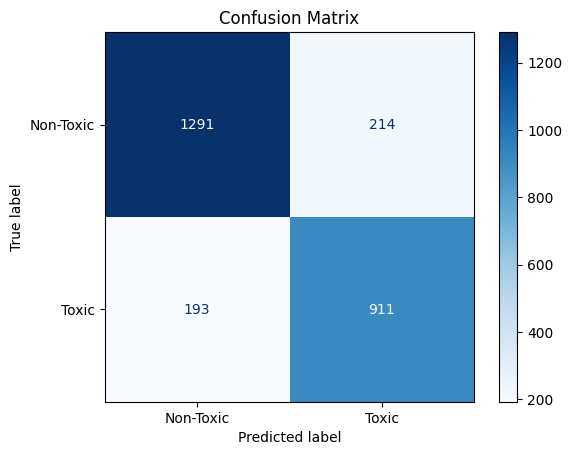

In [9]:
# TODO: buat confusion matrix
cm = confusion_matrix(y_test, y_pred )

# Tampilkan dengan display labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Toxic', 'Toxic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

---
## 9. Inspeksi: Kata Paling Berpengaruh

**Konteks:** Ini salah satu keunggulan Logistic Regression dibanding model kompleks — kita bisa lihat *kata apa* yang paling mempengaruhi prediksi. Ini disebut **model interpretability**.

Logistic Regression menyimpan bobot (coefficients) untuk setiap fitur:
- Koefisien positif tinggi → kata tersebut mendorong prediksi ke label 1 (toxic)
- Koefisien negatif tinggi → kata tersebut mendorong prediksi ke label 0 (non-toxic)

**Instruksi:**
- Ambil koefisien model dengan `model.coef_[0]`
- Buat DataFrame berisi `feature_names` dan `coef`-nya
- Sort descending untuk top 20 kata paling toxic
- Sort ascending untuk top 20 kata paling non-toxic
- Tampilkan keduanya

In [10]:
# Boilerplate — baca dan pahami, tidak perlu dihafal
coef_df = pd.DataFrame({
    'kata': feature_names,
    'koefisien': model.coef_[0]
})

print("=== TOP 20 KATA PALING TOXIC ===")
# TODO: sort descending, tampilkan 20 teratas
print(coef_df.sort_values('koefisien', ascending=False).head(20))

print("\n=== TOP 20 KATA PALING NON-TOXIC ===")
# TODO: sort ascending, tampilkan 20 teratas
print(coef_df.sort_values('koefisien', ascending=True).head(20))

=== TOP 20 KATA PALING TOXIC ===
                kata  koefisien
755           cebong   6.707356
65              ahok   5.500531
1959            kamu   4.995306
2439      lengserkan   4.438198
1828          jokowi   4.432317
4653           tolol   4.424374
3706         prabowo   4.230913
4768            usir   3.979431
667         bubarkan   3.958162
1282  ganti presiden   3.899027
379          bangsat   3.487506
1281           ganti   3.464319
1183           dungu   3.457903
926            dasar   3.286536
382             bani   3.235079
783             cina   3.117564
2959          mundur   2.946315
1893           kafir   2.919128
3656           picek   2.857489
3154            otak   2.562130

=== TOP 20 KATA PALING NON-TOXIC ===
                 kata  koefisien
101               aku  -3.561266
673            budaya  -3.547332
646               bom  -3.115997
2045          katolik  -3.029791
1194          ekonomi  -2.975385
4641            titit  -2.542951
3721  presiden jokowi  -2.

---
## 10. Test Manual

**Konteks:** Sebelum simpan model, uji dengan kalimat buatanmu sendiri. Ini cara paling intuitif untuk mendeteksi kelemahan model.

**Instruksi:**
- Buat fungsi `predict_text(text)` yang:
  1. Menerima string teks mentah
  2. Ubah ke list (vectorizer butuh iterable, bukan string tunggal)
  3. Transform dengan vectorizer
  4. Predict dengan model
  5. Return label string `'TOXIC'` atau `'NON-TOXIC'` beserta confidence score
- Test dengan minimal 5 kalimat berbeda — campurkan yang jelas, ambigu, dan pakai slang

In [19]:
def predict_text(text):
    # TODO: transform teks (ingat: vectorizer butuh list)
    vec = vectorizer.transform([text])
    
    # TODO: predict label
    label = model.predict(vec)[0]
    
    # TODO: ambil probability — gunakan model.predict_proba()
    # hasilnya array [[prob_0, prob_1]], ambil prob_1 (toxic)
    confidence = model.predict_proba(vec)[0][1]
    
    hasil = 'TOXIC' if label == 1 else 'NON-TOXIC'
    print(f"Input     : {text}")
    print(f"Prediksi  : {hasil} (confidence: {confidence:.2%})")
    print()
\

# TODO: test dengan minimal 5 kalimat

predict_text("orang tolol kek gini makannya apasih")
predict_text("haloo guys, aku ada kabar gila nih")
predict_text("woi lu make otak ga sih ")
predict_text("eh lu pada dah milih presiden belom?")
predict_text("udah gendut, idiot lagi")

Input     : orang tolol kek gini makannya apasih
Prediksi  : TOXIC (confidence: 89.09%)

Input     : haloo guys, aku ada kabar gila nih
Prediksi  : NON-TOXIC (confidence: 12.20%)

Input     : woi lu make otak ga sih 
Prediksi  : TOXIC (confidence: 74.47%)

Input     : eh lu pada dah milih presiden belom?
Prediksi  : NON-TOXIC (confidence: 29.76%)

Input     : udah gendut, idiot lagi
Prediksi  : NON-TOXIC (confidence: 25.82%)



---
## 11. Simpan Model & Vectorizer

**Konteks:** Kita harus simpan **dua** objek:
1. `vectorizer` — untuk transform teks baru saat inferensi
2. `model` — untuk predict

Kalau hanya simpan model tapi lupa vectorizer, app tidak bisa jalan.

**Instruksi:**
- Simpan keduanya ke folder `../model/` menggunakan `joblib.dump()`
- Nama file: `vectorizer.joblib` dan `model.joblib`
- Load ulang keduanya untuk konfirmasi tidak error

In [12]:
import os
os.makedirs('../model', exist_ok=True)

# TODO: simpan vectorizer
joblib.dump(vectorizer, '../model/vectorizer.joblib')

# TODO: simpan model
joblib.dump(model, '../model/model.joblib')

# Verifikasi — load ulang
test_vec = joblib.load('../model/vectorizer.joblib')
test_model = joblib.load('../model/model.joblib')
print("Vectorizer loaded:", type(test_vec))
print("Model loaded     :", type(test_model))

Vectorizer loaded: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Model loaded     : <class 'sklearn.linear_model._logistic.LogisticRegression'>


---
## 12. Ringkasan Temuan

Jawab dengan kata-katamu sendiri:

1. Berapa accuracy, precision, recall, dan F1-score model pertamamu?
2. Dari confusion matrix — berapa FN (toxic yang tidak terdeteksi)? Apakah itu angka yang acceptable menurutmu?
3. Dari Section 9, apakah daftar kata toxic masuk akal? Ada yang mengejutkan?
4. Dari test manual — kasus mana yang model paling banyak salah? Kenapa menurutmu?
5. Kenapa kita tidak boleh `fit_transform` pada test set?

*(Tulis jawabanmu di sini)*
1.    precision    recall  f1-score   support

           0       0.87      0.86      0.86      1505
           1       0.81      0.83      0.82      1104

    accuracy                           0.84      2609
2. 193 tweet, menurutku acceptable jika dibandingan TP, ditambah lagi variasi slang dan gaya typing yang banyak
3. hampir semua masuk akal, tapi nama presiden terdeteksi kata toxic, koefisiennya sangat tinggi, mungkin karena tweet yang menyebut nama presiden seringkali hate, jadi model belajar pola itu ya?
4. jika kata toxic eksplisit, model sangat yakin, tapi jika kata diganti singkatan atau kalimat dibuat sarkasme, masih agak sulit model melabeli toxic
5. karena fit berarti belajar, jika belajar pada test set sama dengan melihat kunci jawaban

---
## ✅ Checklist Hari 3
- [ ] Data berhasil di-split train/test dengan stratify
- [ ] TF-IDF hanya di-fit pada train set (tidak leakage)
- [ ] Model berhasil dilatih
- [ ] Classification report dan confusion matrix sudah dilihat dan dipahami
- [ ] Kata paling berpengaruh sudah diinspeksi
- [ ] Test manual dengan 5+ kalimat selesai
- [ ] `vectorizer.joblib` dan `model.joblib` tersimpan di folder `model/`
- [ ] Ringkasan temuan diisi